<a href="https://colab.research.google.com/github/Muskan-Sh-23/Machine-learning/blob/main/Support_Vector_Machine/Polynomial_SVM_from_Scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Polynomial SVM from Scratch (SMO)

From-scratch implementation of a Polynomial Kernel Support Vector Machine using Sequential Minimal Optimization (SMO) on the Two Moons dataset.

## Dataset

The Two Moons dataset contains two interleaving classes that cannot be separated by a single straight line, making it suitable for testing nonlinear classifiers.

In [14]:
#Libraries
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons #data
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

X, Y = make_moons(
    n_samples=300,
    noise=0.15,
    random_state=42
)

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)


In [15]:
# Standardization
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Y_train = np.where(Y_train == 0, -1, 1)
Y_test = np.where(Y_test == 0, -1, 1)

## Polynomial Kernel

The kernel computes similarity in a higher-dimensional feature space without explicitly creating new polynomial features.

<math value="K(x,z)=(x\\cdot z+c)^d" block/>

This implementation uses **degree = 3** and **coef0 = 1**.

In [16]:
def polynomial_kernel(x1, x2, degree=3, coef0=1):
    return (np.dot(x1, x2) + coef0) ** degree

## SMO Optimization

Instead of gradient descent, the model uses **Sequential Minimal Optimization (SMO)**, which updates two Lagrange multipliers (`α`) at a time while satisfying the SVM constraints.

## Model Training

The custom `PolynomialSVM` class learns the support vectors, their coefficients (`α`), and the bias term (`b`) using the polynomial kernel.

In [17]:
class PolynomialSVM:

    def __init__(self, C=1.0, degree=3, coef0=1, tol=1e-3, max_passes=10):
        self.C = C
        self.degree = degree
        self.coef0 = coef0
        self.tol = tol
        self.max_passes = max_passes

    def kernel(self, x1, x2):
        return (np.dot(x1, x2) + self.coef0) ** self.degree   #Kernel Trick

    def fit(self, X, y):

        n_samples = X.shape[0]

        self.X = X
        self.y = y

        self.alpha = np.zeros(n_samples)
        self.b = 0

        passes = 0

        while passes < self.max_passes:

            num_changed = 0

            for i in range(n_samples):

                Ei = self.decision(X[i]) - y[i]

                if (y[i]*Ei < -self.tol and self.alpha[i] < self.C) or \
                   (y[i]*Ei > self.tol and self.alpha[i] > 0):      #KKT Condition

                    j = np.random.randint(0, n_samples)

                    while j == i:
                        j = np.random.randint(0, n_samples)

                    Ej = self.decision(X[j]) - y[j]

                    alpha_i_old = self.alpha[i]
                    alpha_j_old = self.alpha[j]

                    if y[i] != y[j]:
                        L = max(0, self.alpha[j]-self.alpha[i])
                        H = min(self.C, self.C+self.alpha[j]-self.alpha[i])
                    else:
                        L = max(0, self.alpha[i]+self.alpha[j]-self.C)
                        H = min(self.C, self.alpha[i]+self.alpha[j])

                    if L == H:
                        continue

                    kii = self.kernel(X[i], X[i])
                    kjj = self.kernel(X[j], X[j])
                    kij = self.kernel(X[i], X[j])

                    eta = 2*kij - kii - kjj

                    if eta >= 0:
                        continue

                    self.alpha[j] -= y[j]*(Ei-Ej)/eta

                    self.alpha[j] = np.clip(self.alpha[j], L, H)

                    if abs(self.alpha[j]-alpha_j_old) < 1e-5:
                        continue

                    self.alpha[i] += y[i]*y[j]*(alpha_j_old-self.alpha[j])

                    b1 = self.b - Ei \
                         - y[i]*(self.alpha[i]-alpha_i_old)*kii \
                         - y[j]*(self.alpha[j]-alpha_j_old)*kij

                    b2 = self.b - Ej \
                         - y[i]*(self.alpha[i]-alpha_i_old)*kij \
                         - y[j]*(self.alpha[j]-alpha_j_old)*kjj

                    if 0 < self.alpha[i] < self.C:
                        self.b = b1
                    elif 0 < self.alpha[j] < self.C:
                        self.b = b2
                    else:
                        self.b = (b1+b2)/2

                    num_changed += 1

            if num_changed == 0:
                passes += 1
            else:
                passes = 0

        return self

    def decision(self, x):

        result = self.b

        for alpha, yi, xi in zip(self.alpha, self.y, self.X):
            if alpha > 1e-6:
                result += alpha*yi*self.kernel(xi, x)

        return result

    def predict(self, X):

        return np.array([
            1 if self.decision(x) >= 0 else -1
            for x in X
        ])

In [18]:
svm = PolynomialSVM(
    C=1,
    degree=3,
    coef0=1
)

svm.fit(X_train, Y_train)

In [19]:
train_pred = svm.predict(X_train)
test_pred = svm.predict(X_test)

## Results

| Metric | Accuracy |
|--------|---------:|
| Training Accuracy | **99.58%** |
| Test Accuracy | **96.67%** |

The small gap between training and test accuracy suggests that the model generalizes well to unseen data.

In [20]:
train_acc = accuracy_score(Y_train, train_pred)
test_acc = accuracy_score(Y_test, test_pred)

print("Training Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Training Accuracy: 0.9958333333333333
Test Accuracy: 0.9666666666666667


## Decision Boundary

The learned boundary follows the two moon-shaped classes by combining support-vector votes through the polynomial kernel.

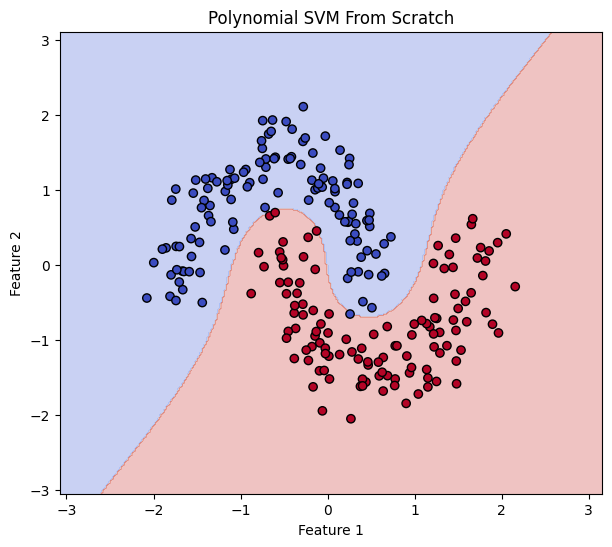

In [21]:
x_min, x_max = X_train[:,0].min()-1, X_train[:,0].max()+1
y_min, y_max = X_train[:,1].min()-1, X_train[:,1].max()+1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]
Z = svm.predict(grid)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(7,6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")

plt.scatter(
    X_train[:,0],
    X_train[:,1],
    c=Y_train,
    cmap="coolwarm",
    edgecolors="k"
)

plt.title("Polynomial SVM From Scratch")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

## Observations

- The Polynomial Kernel learns a nonlinear decision boundary.
- SMO optimizes `α` values instead of learning weights directly.
- Only support vectors contribute to the final decision function.
- The model achieved strong performance on unseen test data.

## Conclusion

This implementation builds a Polynomial Kernel SVM from scratch by combining a custom kernel with SMO optimization, demonstrating how support vectors and Lagrange multipliers create nonlinear decision boundaries without using `sklearn.SVC`.